In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
db = pd.read_csv('loan_data.csv')

In [ ]:
# displaying the first 5 rows
db.head()

,applicant_id,age,gender,marital_status,city_tier,state,employment_type,bank_account_vintage_years,monthly_income_inr,existing_loans_count,...,num_credit_inquiries_last_6m,late_payments_last_12m,loan_amount_requested_inr,loan_tenure_months,loan_purpose,collateral_provided,cibil_score,interest_rate_offered_pct,default_risk_score,default_flag
0,APP106868,22,Male,Single,Tier 3,Haryana,Salaried - PSU,0.5,12000,1,...,2.0,0,149000,48,Personal Expense,No,649,24.84,1.67,0
1,APP124016,35,Female,Divorced,Tier 2,Gujarat,Salaried - Private,0.5,32500,3,...,0.0,1,156000,60,Personal Expense,No,538,25.25,4.47,0
2,APP109668,41,Male,Married,Tier 2,Uttar Pradesh,Salaried - Government,2.8,52500,0,...,0.0,0,70000,36,Wedding,No,636,20.46,0.19,0
3,APP113640,29,Female,Married,Tier 2,Kerala,Salaried - PSU,0.7,15500,1,...,0.0,1,108000,48,Education,No,721,15.27,0.26,0
4,APP114018,31,Male,Married,Tier 1,Punjab,Self-Employed Professional,4.7,269600,2,...,0.0,2,466000,24,Education,No,586,25.52,2.10,0


In [ ]:
# displaying the data shape
db.shape

(25000, 22)

In [ ]:
# displaying column names and data types for each one
db.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   applicant_id                  25000 non-null  str    
 1   age                           25000 non-null  int64  
 2   gender                        25000 non-null  str    
 3   marital_status                25000 non-null  str    
 4   city_tier                     25000 non-null  str    
 5   state                         25000 non-null  str    
 6   employment_type               25000 non-null  str    
 7   bank_account_vintage_years    24625 non-null  float64
 8   monthly_income_inr            25000 non-null  int64  
 9   existing_loans_count          25000 non-null  int64  
 10  existing_emi_monthly_inr      24500 non-null  float64
 11  credit_utilization_ratio_pct  25000 non-null  float64
 12  num_credit_inquiries_last_6m  24750 non-null  float64
 13  late_payment

In [ ]:
# number of duplicated rows
int(db.duplicated().sum())

0

In [41]:
# number of missing values in each column
missing_counts = db.isnull().sum()
print(missing_counts)

applicant_id                      0
age                               0
gender                            0
marital_status                    0
city_tier                         0
state                             0
employment_type                   0
bank_account_vintage_years      375
monthly_income_inr                0
existing_loans_count              0
existing_emi_monthly_inr        500
credit_utilization_ratio_pct      0
num_credit_inquiries_last_6m    250
late_payments_last_12m            0
loan_amount_requested_inr         0
loan_tenure_months                0
loan_purpose                      0
collateral_provided               0
cibil_score                       0
interest_rate_offered_pct         0
default_risk_score                0
default_flag                      0
dtype: int64


In [17]:
# percentage of missing values in each column
db.isnull().mean()*100

applicant_id                    0.0
age                             0.0
gender                          0.0
marital_status                  0.0
city_tier                       0.0
state                           0.0
employment_type                 0.0
bank_account_vintage_years      1.5
monthly_income_inr              0.0
existing_loans_count            0.0
existing_emi_monthly_inr        2.0
credit_utilization_ratio_pct    0.0
num_credit_inquiries_last_6m    1.0
late_payments_last_12m          0.0
loan_amount_requested_inr       0.0
loan_tenure_months              0.0
loan_purpose                    0.0
collateral_provided             0.0
cibil_score                     0.0
interest_rate_offered_pct       0.0
default_risk_score              0.0
default_flag                    0.0
dtype: float64

In [ ]:
# mean, std, count, etc for all numerical inputs
db.describe()

,age,bank_account_vintage_years,monthly_income_inr,existing_loans_count,existing_emi_monthly_inr,credit_utilization_ratio_pct,num_credit_inquiries_last_6m,late_payments_last_12m,loan_amount_requested_inr,loan_tenure_months,cibil_score,interest_rate_offered_pct,default_risk_score,default_flag
count,25000.000000,24625.000000,25000.000000,25000.000000,24500.000000,25000.000000,24750.000000,25000.000000,2.500000e+04,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,35.303520,3.999647,54832.428000,1.103720,11705.636735,41.590360,1.298869,1.446680,1.584572e+05,42.401760,615.290640,20.714922,6.271094,0.061400
std,8.561309,3.900615,38347.488163,1.051421,10297.365558,19.804901,1.136458,1.271071,1.042315e+05,19.223168,63.057171,3.413218,11.938843,0.240067
min,21.000000,0.500000,12000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.500000e+04,12.000000,360.000000,10.570000,0.000000,0.000000
25%,29.000000,1.100000,29500.000000,0.000000,5100.000000,27.800000,0.000000,0.000000,8.800000e+04,24.000000,573.750000,18.810000,0.530000,0.000000
50%,35.000000,2.800000,45100.000000,1.000000,9000.000000,41.300000,1.000000,1.000000,1.330000e+05,36.000000,617.000000,21.050000,1.770000,0.000000
75%,41.000000,5.500000,68700.000000,2.000000,15100.000000,55.000000,2.000000,2.000000,1.990000e+05,60.000000,659.000000,23.510000,5.852500,0.000000
max,65.000000,25.000000,727000.000000,6.000000,202300.000000,100.000000,9.000000,8.000000,1.519000e+06,84.000000,866.000000,26.000000,99.080000,1.000000


The initial data inspection reveals a severe class imbalance. Additionally, missing data is minimal and strictly confined to three numerical features (existing_emi_monthly_inr, bank_account_vintage_years, and num_credit_inquiries_last_6m), which will be resolved using median imputation during preprocessing.

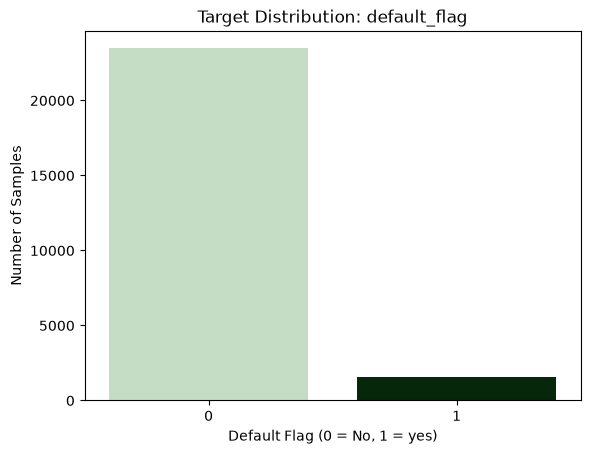

In [54]:
# Target Distribution Plot
target = 'default_flag'
#plt.figure(figsize=(6, 4))
sns.countplot(data = db, x = target, hue=target, legend=False, palette=['#C1E1C1', '#002D04'])
plt.title('Target Distribution: default_flag')
plt.xlabel('Default Flag (0 = No, 1 = yes)')
plt.ylabel('Number of Samples')
plt.show()

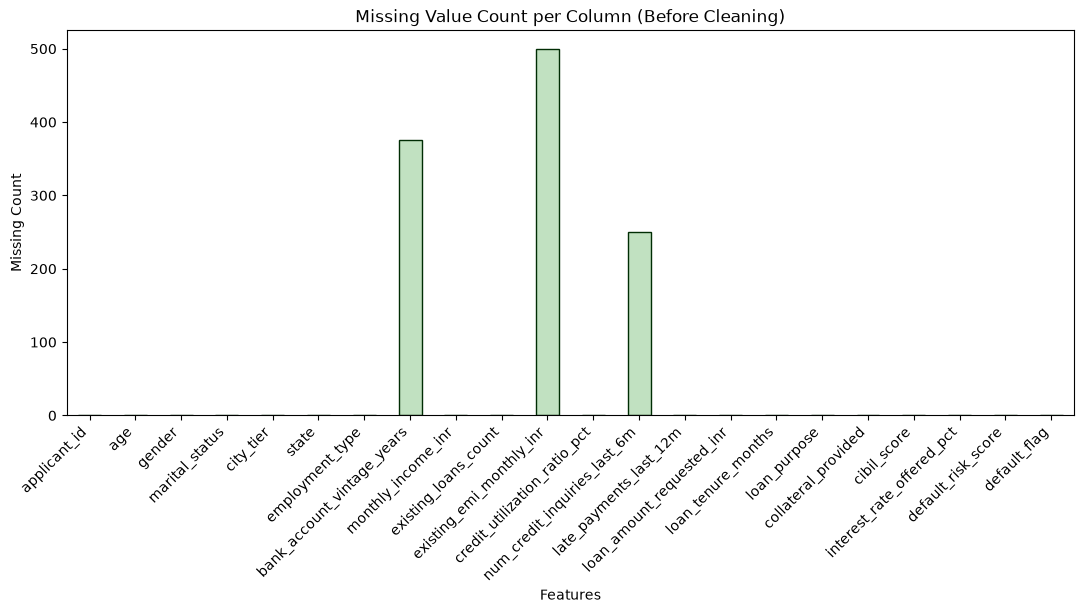

In [53]:
# Missing Values Bar Plot (Raw Data)
plt.figure(figsize=(13, 5))
missing_counts.plot(kind='bar', color='#C1E1C1', edgecolor='#002D04')
plt.title('Missing Value Count per Column (Before Cleaning)')
plt.xlabel('Features')
plt.ylabel('Missing Count')
plt.xticks(rotation=45, ha='right')
plt.show()

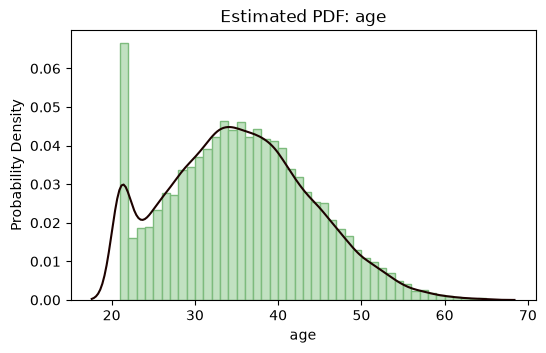

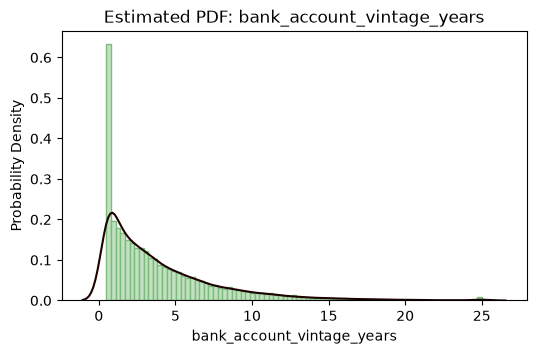

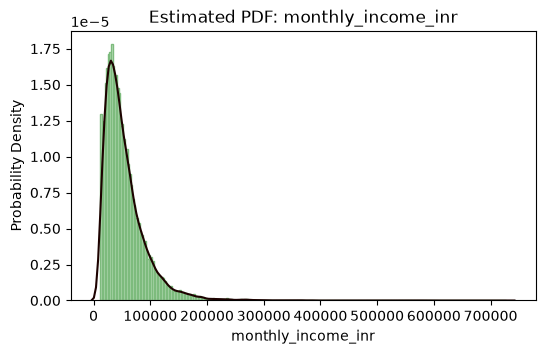

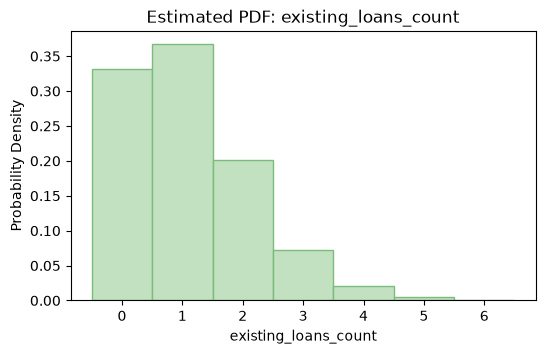

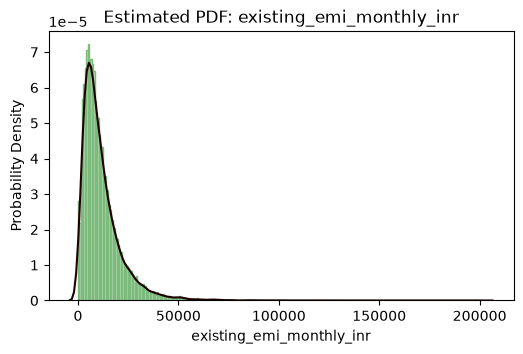

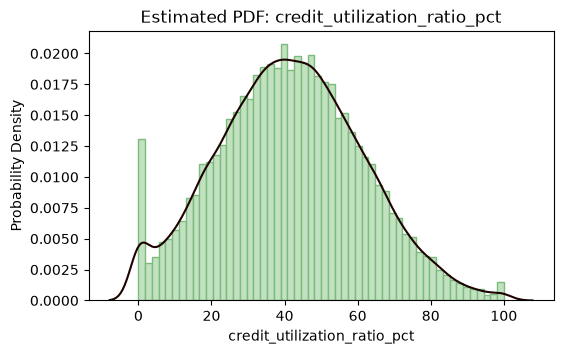

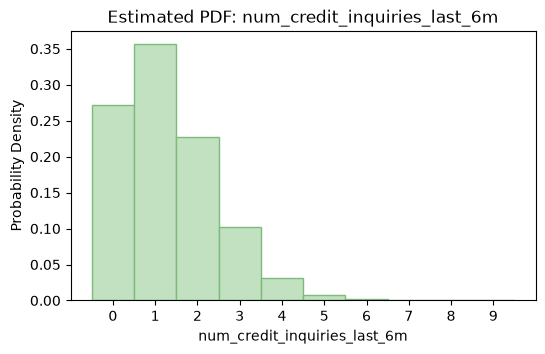

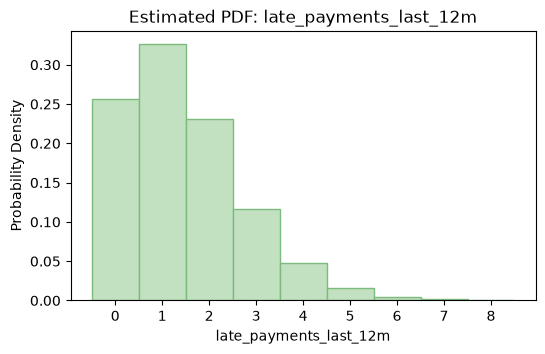

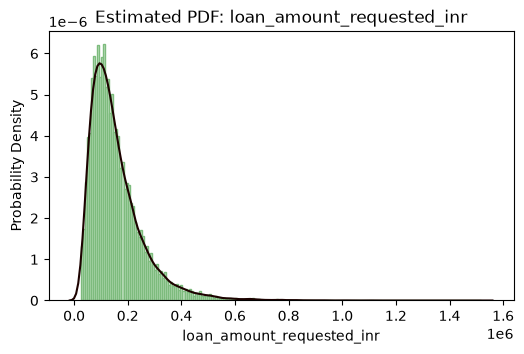

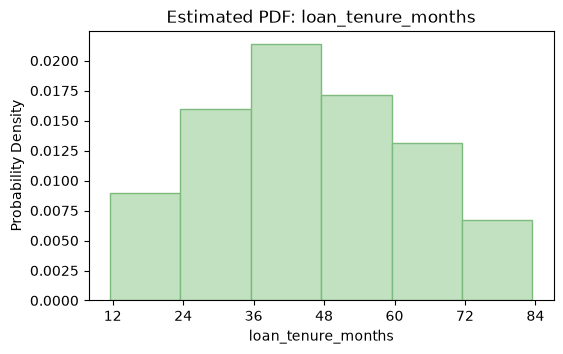

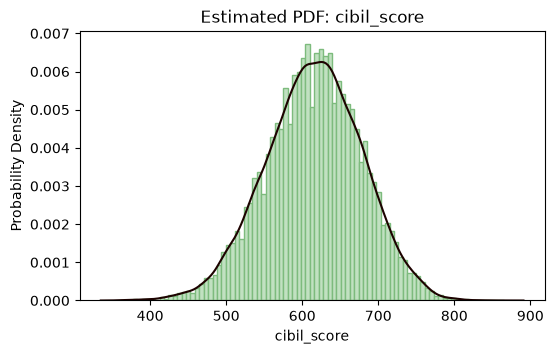

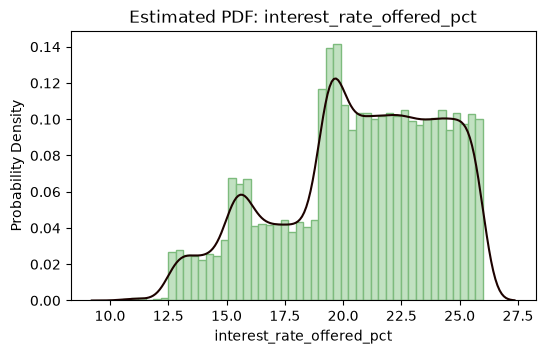

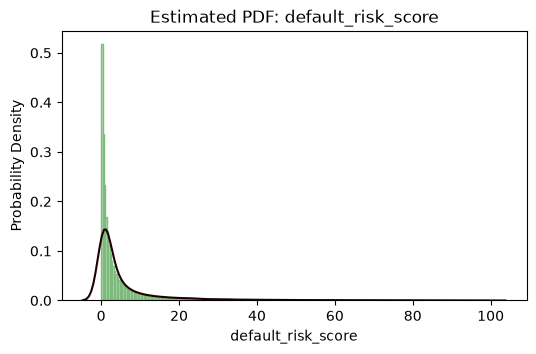

In [ ]:
# Isolate numerical columns then dropping ID and target
num_cols = db.select_dtypes(include=['float64', 'int64']).columns
num_cols = num_cols.drop(['applicant_id', 'default_flag'], errors='ignore')

# Plot estimated PDF for every numerical feature
for col in num_cols:
    vals = db[col].dropna()
    is_discrete = vals.nunique()<=15 and (vals%1==0).all

    plt.figure(figsize=(6, 3.5))
    
    # density=True ensures the histogram area integrates to 1
    if is_discrete:
        if col == "loan_tenure_months":
            bins = np.arange(vals.min() - 6, vals.max() + 18, 12)
            plt.hist(db[col].dropna(), bins=bins, density=True, color='#C1E1C1', edgecolor='#7DBB7D')  
            plt.xticks(range(int(vals.min()), int(vals.max()) + 1, 12))
        else:
            bins = np.arange(vals.min() - 0.5, vals.max() + 1.5, 1)
            plt.hist(db[col].dropna(), bins=bins, density=True, color='#C1E1C1', edgecolor='#7DBB7D')  
            plt.xticks(range(int(vals.min()), int(vals.max()) + 1))
    else:
        plt.hist(db[col].dropna(), bins='fd', density=True, color='#C1E1C1', edgecolor='#7DBB7D')
        sns.kdeplot(db[col].dropna(), color='#1D0200', linewidth=1.5)
    
    plt.title(f'Estimated PDF: {col}')
    plt.xlabel(col)
    plt.ylabel('Probability Density')
    plt.show()

The estimated PDFs show that features like monthly_income_inr, existing_emi_monthly_inr, loan_amount_requested_inr, and default_risk_score are heavily right-skewed, indicating that most applicants fall on the lower end with a few extreme high-value outliers. Conversely, cibil_score and credit_utilization_ratio_pct follow near-normal distributions, while interest_rate_offered_pct exhibits a distinct multi-modal shape, and discrete features like late_payments_last_12m show sharp peaks at specific integers.

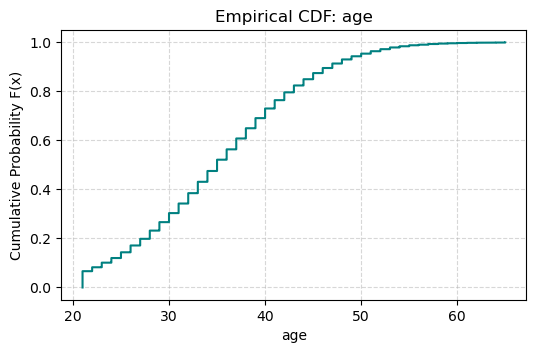

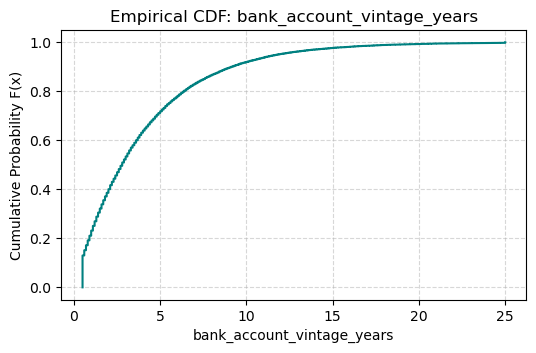

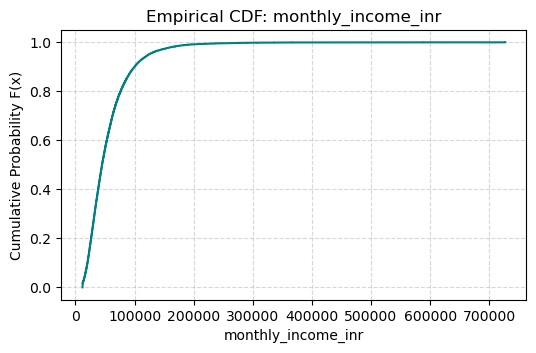

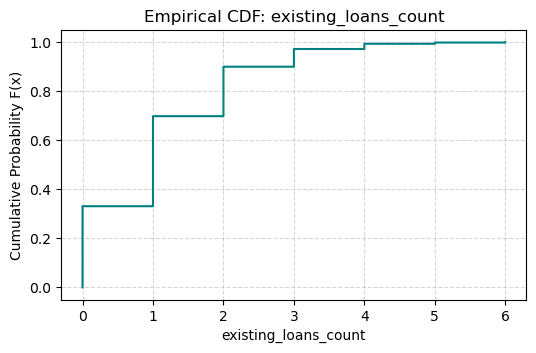

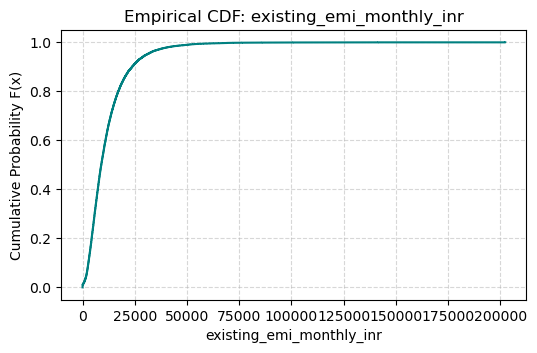

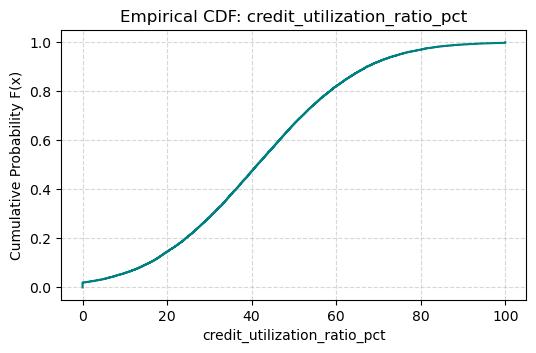

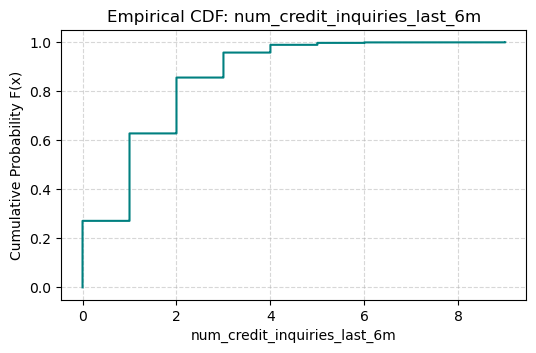

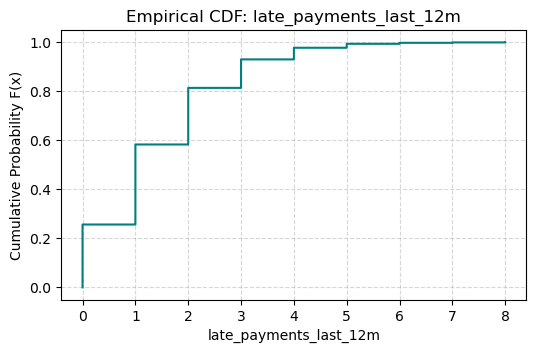

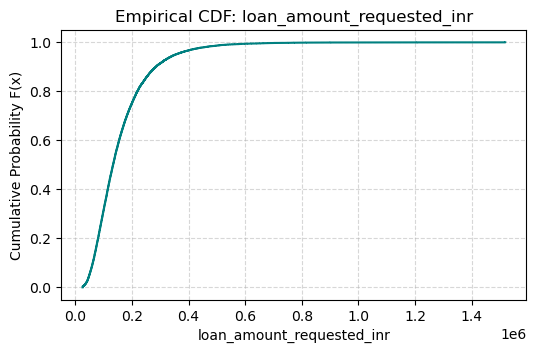

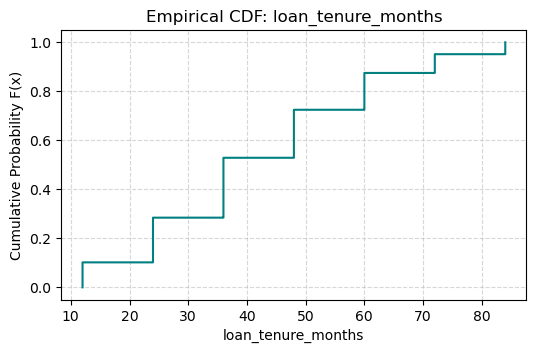

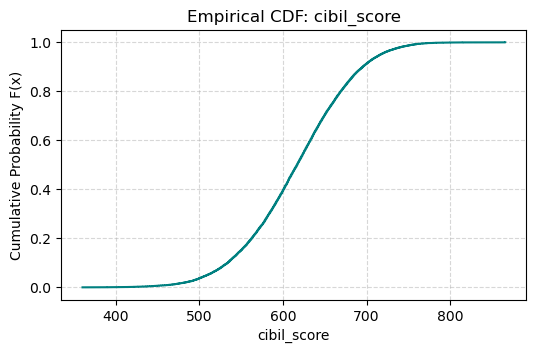

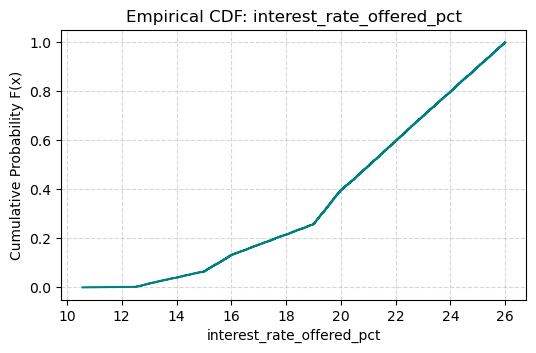

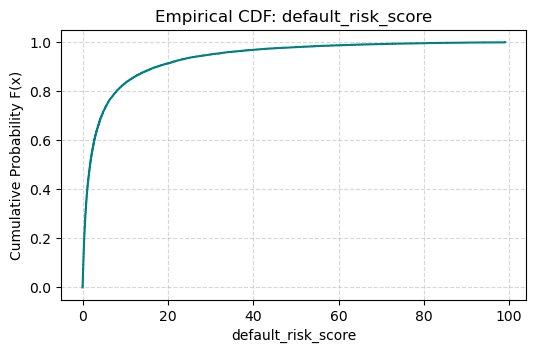

In [17]:
# Plot empirical CDF for every numerical feature
for col in num_cols:
    data_sorted = np.sort(db[col].dropna())
    ecdf = np.arange(1, len(data_sorted) + 1) / len(data_sorted)
    
    plt.figure(figsize=(6, 3.5))
    plt.step(data_sorted, ecdf, where='post', color='teal', linewidth=1.5)
    plt.title(f'Empirical CDF: {col}')
    plt.xlabel(col)
    plt.ylabel('Cumulative Probability F(x)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

The Empirical CDF plots confirm the heavy right-skew observed in the density plots, showing that roughly 80% to 90% of applicants fall into the lower ranges for monthly_income_inr, existing_emi_monthly_inr, loan_amount_requested_inr, and default_risk_score, before the curve flattens out due to long-tail outliers. In contrast, the smooth, S-shaped curves of cibil_score and credit_utilization_ratio_pct confirm their normal distribution, while the stark, step-like progression in existing_loans_count, num_credit_inquiries_last_6m, and late_payments_last_12m highlights their discrete, categorical-like nature.

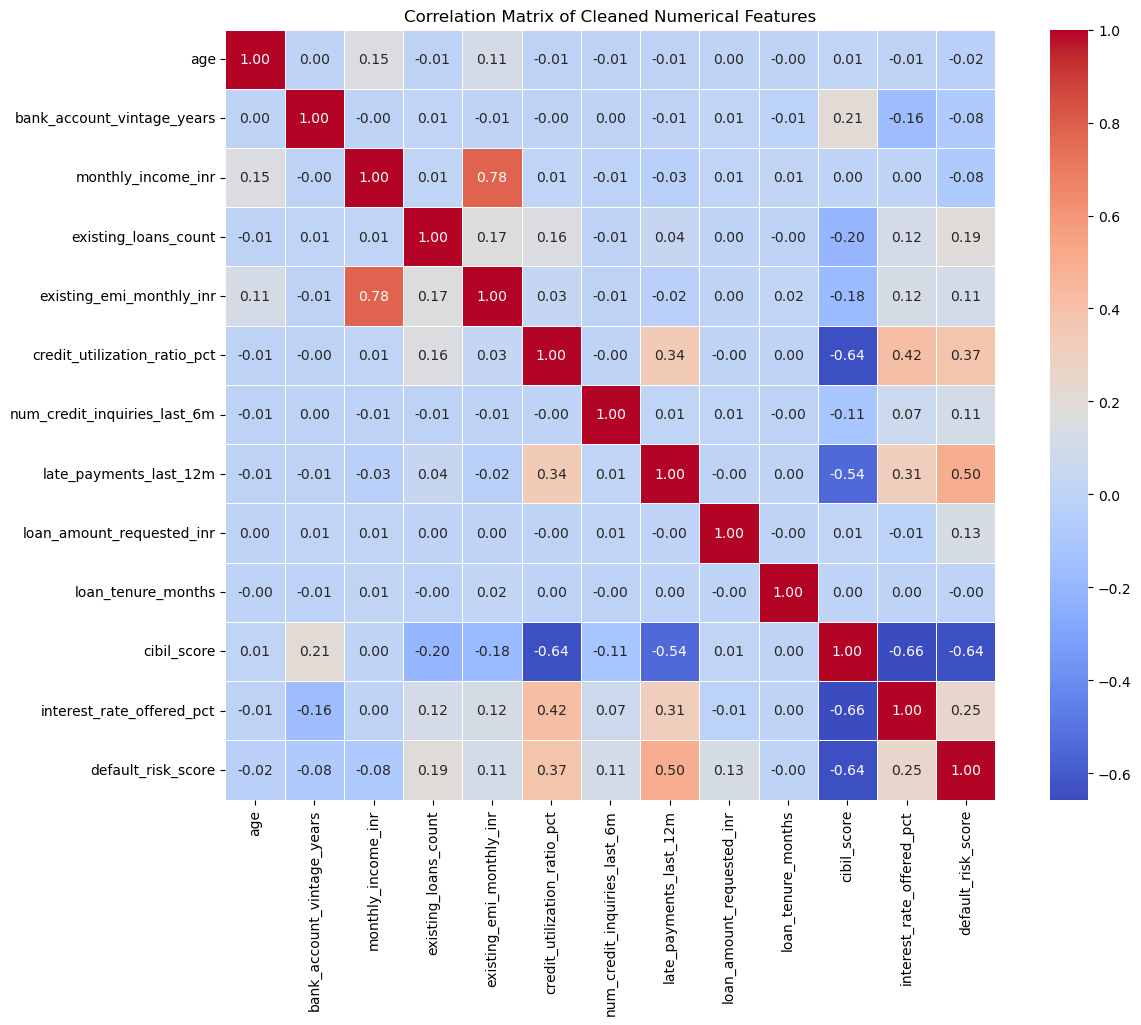

In [18]:
# Create a copy to preserve original data for EDA comparison
db_cleaned = db.copy()

# 1. Remove exact duplicate rows
db_cleaned = db_cleaned.drop_duplicates()

# 2. Remove rows where the target (default_flag) is missing
db_cleaned = db_cleaned.dropna(subset=['default_flag'])

# 3. Fill missing numerical input values with the median of that feature
for col in num_cols:
    median_value = db_cleaned[col].median()
    db_cleaned[col] = db_cleaned[col].fillna(median_value)

# Generate correlation matrix and heatmap for cleaned numerical features
plt.figure(figsize=(14, 10))
corr_matrix = db_cleaned[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Correlation Matrix of Cleaned Numerical Features')
plt.show()

The correlation matrix reveals a strong positive correlation (0.78) between monthly_income_inr and existing_emi_monthly_inr, which is expected as higher income allows for larger monthly installments. Conversely, cibil_score exhibits significant negative correlations with risk factors like credit_utilization_ratio_pct (-0.64), late_payments_last_12m (-0.54), and default_risk_score (-0.64), demonstrating that a higher credit score strongly inversely correlates with behaviors historically indicative of default.